# Tide adjustment behind the Vlie inlet: one boundary, two methods, one judge

**The question.** Every satellite-derived intertidal DEM assigns a water level
to each scene. That level comes from a *boundary* — an ocean tide model, a
harbour tide gauge, or both — and it is only right at the mouth. Inside the
estuary the tide arrives late, so two published families of methods measure
that lag from the imagery itself and read the boundary on a shifted clock:

| method | what it measures | how | estimator of elevation |
|---|---|---|---|
| **MAREA** (ours) | one clock lag per band of distance from the mouth | profiled Bernoulli likelihood of the binary wet/dry record; only phase is identifiable (affine theorem) so gain and datum stay with the boundary | closed-form NDWI sigmoid, `marea.invert_series` |
| **Granadeiro et al. 2021** | one lag per pixel, smoothed by thin-plate spline | rising vs ebbing logistic fits on standardised NIR, lag that reconciles them, TPS over a sample | 4-parameter logistic on NIR, elevation = inflection |

**The boundary interface.** Two switches, nothing else: `TIDE_MODEL` (a pyTMD
model name, or `None`) and `N_GAUGES` (the N nearest IOC gauges, inverse-
distance blended, or `None`). Both set → the consensus of the two. The same
provider feeds MAREA, Granadeiro and the plain inversion, so what changes
between rows is the *method*, never the data.

**The site.** The Dutch Wadden Sea here has two IOC gauges: Terschelling Noordzee on the sea side of the inlet and Harlingen 28 km in, behind the flats. Harlingen is
**held out** as the judge — never a member of the boundary, never seen by
either fit. A method that claims to measure the interior clock must predict
the level Harlingen measured.

**What we produce**

| product | what it answers |
|---|---|
| bathymetry without vs with MAREA | what the measured clock does to the map (same inversion, only the clock changes) |
| MAREA vs Granadeiro | two clocks, two estimators — and a crossed row that isolates the clock from the estimator |
| lag against the gauge pair | the lag between the mouth gauge and Harlingen in reaching the same level, their level difference at the same instant, and the level error at Harlingen — MAREA with and without the lag applied |
| elevation against the external reference | the three maps against the IGN 5 m LiDAR (Spanish sites) or the Rijkswaterstaat Vaklodingen (Dutch sites) |

**Two decisions, stated up front.**

1. *Without vs with MAREA* uses the **same inversion** (`marea.invert_series`)
   on the same pixels and scenes; only the level series differs. Anything else
   would confound the clock with the estimator.
2. *MAREA vs Granadeiro* keeps **each method's own estimator**, because the
   published method is the whole recipe, not just its lag. A **crossed row**
   — Granadeiro's lag map fed into our inversion — then separates what the
   clock contributes from what the estimator contributes.

## Parameters

Everything that changes between one run and another lives in the next cell.
`TIDE_MODEL` and `N_GAUGES` are the two boundary switches; `JUDGE_GAUGES`
names the instruments held out from the boundary, whatever their distance.

In [ ]:
# ── Which area, and over what period ────────────────────────────────────
SITE         = "wadden"                       # registry key
TIME_EXTENT  = ("2023-01-01", "2025-12-31")
RESOLUTION_M = 10                              # the cached cube's grid (20 m until 2026-09-30)
CACHE        = "ndwi_cube_wadden_2023-2025_10m.nc"   # python -m experiments.download_cube wadden
OUT_DIR      = "products_wadden_10m"
MIN_SCENES   = 40                             # record floor for the lag fit: the
                              # transition-zone scene rule leaves 48-106 scenes

# ── The boundary: two switches ──────────────────────────────────────────
TIDE_MODEL   = "EOT20"        # pyTMD model name, or None
N_GAUGES     = 1              # N nearest IOC gauges (IDW blend), or None
JUDGE_GAUGES = ['harl']       # held out: never in the boundary (Harlingen)
MOUTH_SIDE   = "north+west"   # the sea is on the north and west edges of the box:
                              # distance from the mouth is measured from
                              # the sea on those edge(s) only

# ── Derived ─────────────────────────────────────────────────────────────
BOUNDARY_TAG = f"{(TIDE_MODEL or 'nomodel').lower()}_g{N_GAUGES or 0}"
print(f"run {SITE!r} · {TIME_EXTENT[0]} → {TIME_EXTENT[1]} @ {RESOLUTION_M} m")
print(f"  boundary  model={TIDE_MODEL}  gauges={N_GAUGES}  "
      f"held out={JUDGE_GAUGES}  → tag {BOUNDARY_TAG}")
print(f"  cache     {CACHE}")
print(f"  outputs   {OUT_DIR}")

## 0 · Setup

No Copernicus connection is needed: the cube is cached. The certificate fix is
still required, because the overpass times come from the catalogue.

In [2]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyintertidal as pit
from pyintertidal import SentinelCube, explain, viz, marea
from pyintertidal import tide_estimators as te
from pyintertidal.boundary import make_boundary, nearest_gauges
from pyintertidal.gauges import load_cached_ioc, despike

pit.net.use_system_certificates()
os.makedirs(OUT_DIR, exist_ok=True)
print("pyintertidal", pit.__version__)
log = explain.OpLog(f"Escalda {TIME_EXTENT[0][:4]}–{TIME_EXTENT[1][:4]}")

pyintertidal 0.1.0


## 1 · Study area and its instruments

The polygon comes from the registry. The gauges come from the IOC station
list: the N nearest that are not held out form the boundary, the held-out
ones judge.

AOI('Wadden (Vlie-Harlingen)', 888.7 km², [5.150, 53.150, 5.550, 53.450])
  centroid 53.300, 5.350

IOC gauges around the site:
  ters  Terschelling Noordzee         14.3 km   BOUNDARY member
  harl  Harlingen                     14.4 km   JUDGE (held out)
  denh  Den Helder                    55.1 km   unused
  bork  Borkum Fischerbalje           97.0 km   unused
  delf  Delfzijl                     105.2 km   unused
  sche  Scheveningen                 152.3 km   unused


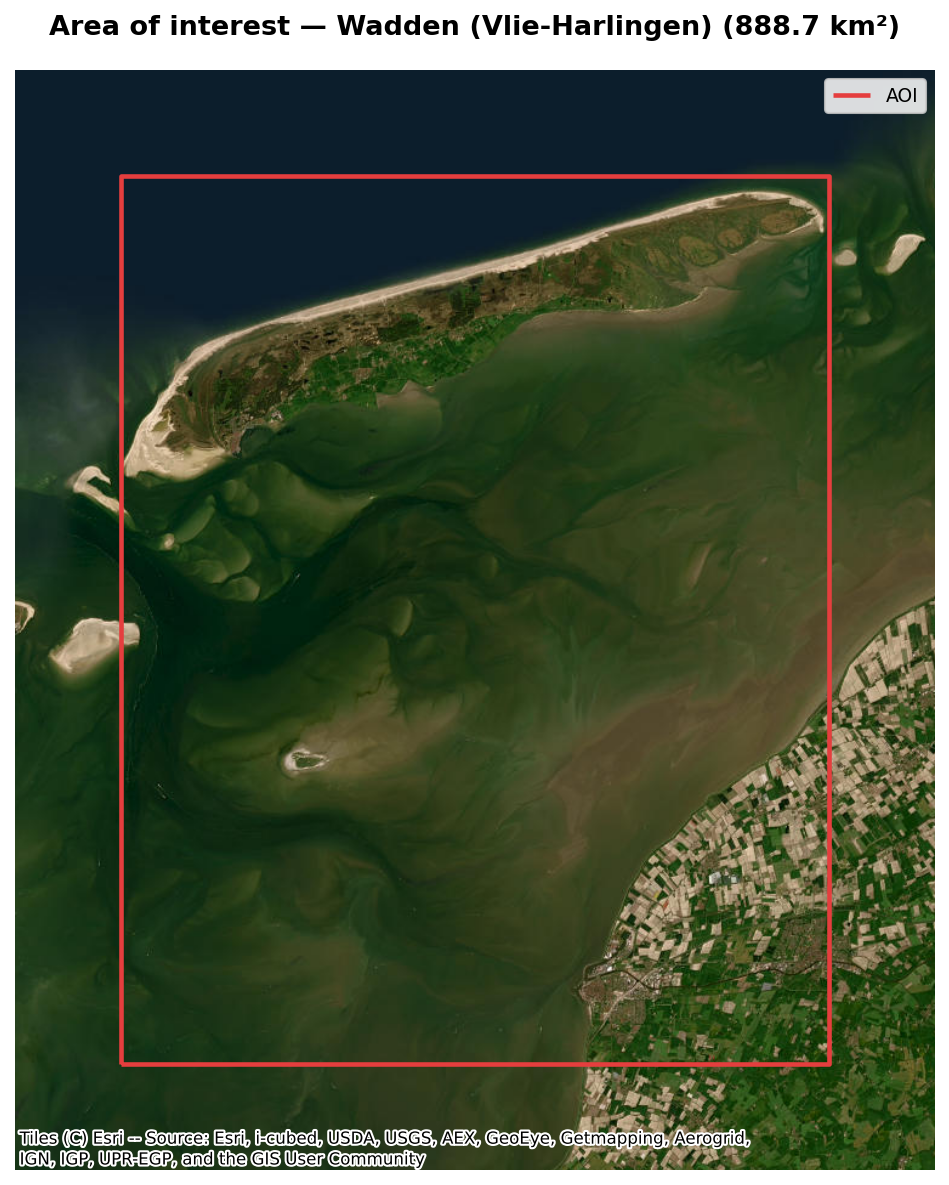

In [3]:
aoi = pit.sites.get(SITE)
print(aoi)
lat_c, lon_c = aoi.centroid
print(f"  centroid {lat_c:.3f}, {lon_c:.3f}")

stations = {s["Code"]: s for s in json.load(
    open("data_v4/gauges/ioc_stations.json", encoding="utf-8"))}
near = nearest_gauges(lat_c, lon_c, 6)
members = [g for g in near if g[0] not in JUDGE_GAUGES][:(N_GAUGES or 0)]
member_codes = [g[0] for g in members]
print("\nIOC gauges around the site:")
for code_, name, km in near:
    role = ("BOUNDARY member" if code_ in member_codes else
            "JUDGE (held out)" if code_ in JUDGE_GAUGES else "unused")
    print(f"  {code_:5s} {name:28s} {km:5.1f} km   {role}")
viz.plot_aoi(aoi);

## 2 · The datacube

Cached at 10 m for 2023–2025 (B03, B08, SCL), downloaded beforehand with
`python -m experiments.download_cube wadden`. Every later step streams it.

In [4]:
WATER = "ndwi"
cube = SentinelCube(aoi, TIME_EXTENT, water=WATER, cache_path=CACHE,
                    resolution=RESOLUTION_M)
cube.ensure(None)                       # cached → no connection needed
transform, crs = cube.grid
H, W = cube.shape
px_km2 = abs(transform.a * transform.e) / 1e6
print(f"{len(cube.dates)} scenes · grid {H}×{W} @ {abs(transform.a):g} m · {crs}")
explain.dates_available(cube.dates, TIME_EXTENT)

[cube] using cache ndwi_cube_wadden_2023-2025_20m.nc


462 scenes · grid 1713×1389 @ 20 m · EPSG:32631


<pyintertidal summary — display it in a notebook>

## 3 · Water detection threshold

Otsu over the clearest scenes suggests the cut; the adopted value is written
out. MAREA's extraction uses the same convention (wet when NDWI > 0).

In [5]:
otsu, info = pit.water.calibrate_threshold(cube, n_scenes=12)
NDWI_THRESHOLD = 0.0
print(f"\nadopted NDWI threshold: {NDWI_THRESHOLD:+.3f}")

[water] Otsu on 402,528 clear pixels from 12 scenes → +0.250  (clipped — the sample was not clearly bimodal; set the threshold manually)

adopted NDWI threshold: +0.000


## 4 · Coastal stability, cloud screening, water frequency, intertidal zone

The same four steps as the Villaviciosa study, with the same parameters.

  class 0 (transition   ):  985,009 px  394.00 km²
  class 1 (stable water ): 1,132,470 px  452.99 km²
  class 2 (stable land  ):  261,878 px  104.75 km²
71 usable dates


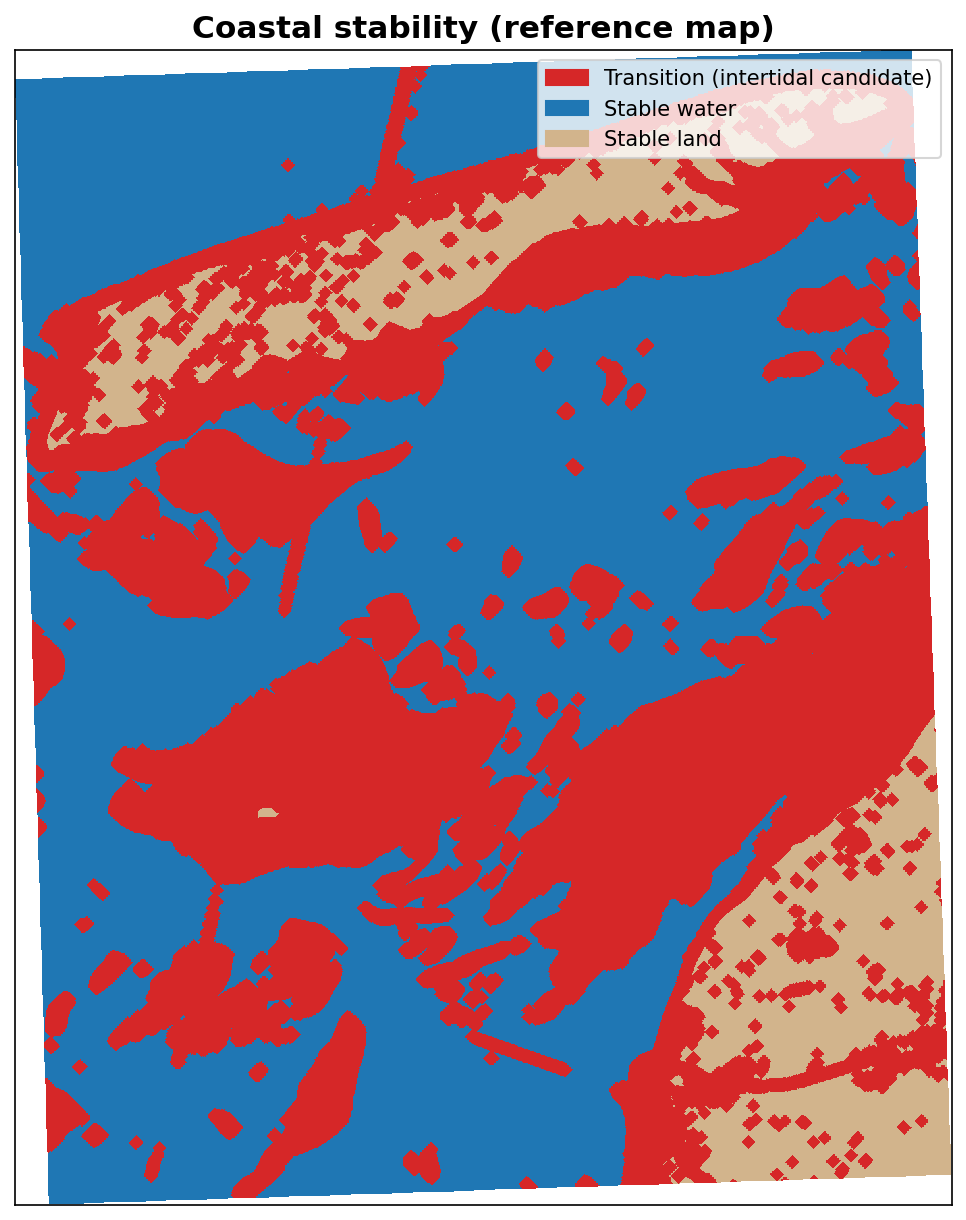

In [6]:
CLEAN_SCENE_MAX_BAD  = 0.05
STABLE_THRESHOLD     = 0.95
TRANSITION_BUFFER_PX = 10
CLOUD_THRESHOLD      = 0.10

reference_map, cloud_pct = pit.reference_and_clouds(
    cube, threshold=NDWI_THRESHOLD, bad_classes=pit.water.BAD_CLASSES,
    clean_scene_max_bad=CLEAN_SCENE_MAX_BAD, stable_threshold=STABLE_THRESHOLD,
    transition_buffer_px=TRANSITION_BUFFER_PX)
for code_, name in [(0, "transition"), (1, "stable water"), (2, "stable land")]:
    n = int((reference_map == code_).sum())
    print(f"  class {code_} ({name:13s}): {n:>8,} px  {n * px_km2:6.2f} km²")
usable_dates = pit.filter_dates(cloud_pct, cloud_threshold=CLOUD_THRESHOLD)
# MAREA's scene record: "transition" (the transition-zone rule above) or
# "all" (every scene of the period, clouds masked per pixel). The choice is
# the truth-free decision of experiments/v12_scene_rule_choice.py when it
# has been run (results/scene_rule_choice/decision.json).
import json as _json, os as _os
_DEC = "results/scene_rule_choice/decision.json"
SCENE_RULE = _json.load(open(_DEC))["choice"] if _os.path.exists(_DEC) else "transition"
print(f"MAREA scene record: {SCENE_RULE}")
print(f"{len(usable_dates)} usable dates")
log.record("reference map + cloud stats", kind="reduce",
           params={"stable_threshold": STABLE_THRESHOLD}, inputs=["cube"],
           outputs=["reference map", f"{len(usable_dates)} dates"])
viz.plot_reference_map(reference_map, transform, crs, aoi);

multi-Otsu window [0.25, 0.80]; adopted [0.05, 0.95] → intertidal 459,487 px = 183.79 km²


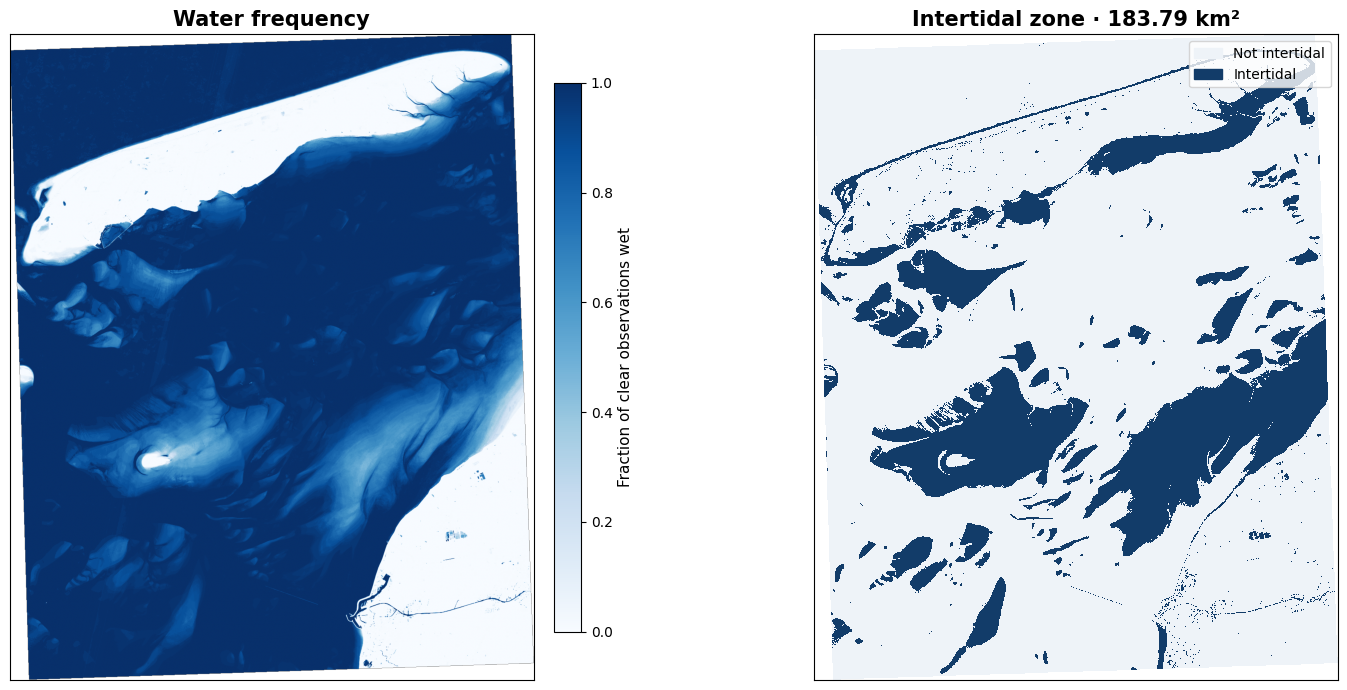

In [7]:
MIN_OBS = max(8, round(0.05 * len(usable_dates)))
water_freq = pit.water_frequency(cube, dates=usable_dates,
                                 threshold=NDWI_THRESHOLD, min_obs=MIN_OBS)
transition = reference_map == 0
otsu_low, otsu_high = pit.multiotsu_window(water_freq, transition)
WF_LOW, WF_HIGH = 0.05, 0.95
polygon_mask = aoi.raster_mask(transform, crs, reference_map.shape)
intertidal = pit.intertidal_mask(water_freq, reference_map, WF_LOW, WF_HIGH,
                                 aoi_mask=polygon_mask)
area_km2 = intertidal.sum() * px_km2
print(f"multi-Otsu window [{otsu_low:.2f}, {otsu_high:.2f}]; adopted "
      f"[{WF_LOW}, {WF_HIGH}] → intertidal {int(intertidal.sum()):,} px = "
      f"{area_km2:.2f} km²")
log.record("intertidal mask", kind="mask", params={"wf": [WF_LOW, WF_HIGH]},
           outputs=["intertidal mask"], note=f"{area_km2:.2f} km²")
fig, axes = plt.subplots(1, 2, figsize=(19, 7))
viz.plot_water_frequency(water_freq, transform, crs, aoi, ax=axes[0])
viz.plot_intertidal(intertidal, transform, crs, aoi,
                    title=f"Intertidal zone · {area_km2:.2f} km²", ax=axes[1])
fig.tight_layout();

## 5 · The boundary

One call builds the provider from the two switches. Whatever it is — model,
gauges or consensus — the rest of the notebook only ever calls
`boundary.levels(times)`.

The three options are drawn together over a spring tide so the differences
are visible: the gauges carry surge and the harbour's own harmonics, the
model carries neither; the consensus halves both.

Two honesties about gauge records. IOC files carry sentinel spikes (a few
samples at −10 m) and holes (Vlissingen is dark from 2023-09 to 2025-03):
`make_boundary` drops the spikes with a rolling-median rule and never bridges
a hole — a missing gauge simply leaves the blend, and when every gauge is
missing the consensus falls back to the model alone (about 6 % of this
period). The judge record below is cleaned with the same rule.

[boundary] gauge ters (Terschelling Noordzee) at 14 km: 146,697 samples (510 spikes dropped)
boundary: consensus EOT20 + ters


Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

  model EOT20            range [-1.55, +1.52] m, finite 100.0%

  1 nearest gauges       range [-2.00, +2.36] m, finite 93.6%

  consensus              range [-1.65, +1.62] m, finite 100.0%

  boundary               range [-1.65, +1.62] m, finite 100.0%

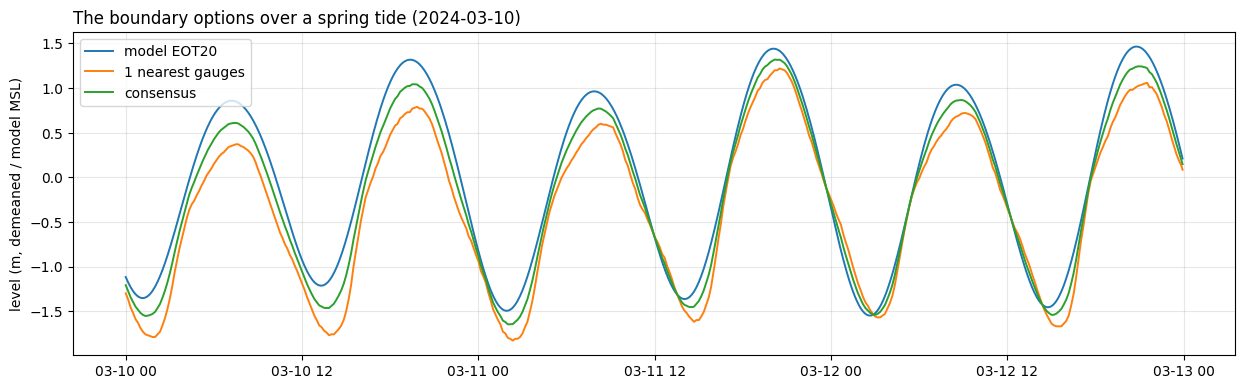

In [8]:
boundary = make_boundary(aoi, tide_model=TIDE_MODEL, n_gauges=N_GAUGES,
                         period=TIME_EXTENT, exclude=JUDGE_GAUGES)
print(f"boundary: {boundary.name}")

# the alternatives, for the record (cached gauges → cheap)
options = {}
if TIDE_MODEL:
    options[f"model {TIDE_MODEL}"] = make_boundary(
        aoi, TIDE_MODEL, None, period=TIME_EXTENT, exclude=JUDGE_GAUGES,
        verbose=False)
if N_GAUGES:
    options[f"{N_GAUGES} nearest gauges"] = make_boundary(
        aoi, None, N_GAUGES, period=TIME_EXTENT, exclude=JUDGE_GAUGES,
        verbose=False)
if TIDE_MODEL and N_GAUGES:
    options["consensus"] = boundary

# a 5-minute grid of every option over the whole period: the record every
# metric below reads, shifted in time by interpolation when a clock applies
grid5 = pd.date_range(TIME_EXTENT[0], pd.Timestamp(TIME_EXTENT[1]) + pd.Timedelta(days=1),
                      freq="5min")
lev5 = {k: np.asarray(v.levels(grid5), float) for k, v in options.items()}
lev5["boundary"] = np.asarray(boundary.levels(grid5), float)
for k, v in lev5.items():
    print(f"  {k:22s} range [{np.nanmin(v):+.2f}, {np.nanmax(v):+.2f}] m, "
          f"finite {np.isfinite(v).mean():.1%}")

# three days around a spring tide
rng_day = pd.Series(lev5["boundary"], index=grid5).resample("1D").agg(
    lambda x: np.nanmax(x) - np.nanmin(x))
d0 = rng_day.idxmax() - pd.Timedelta(days=1)
win = (grid5 >= d0) & (grid5 < d0 + pd.Timedelta(days=3))
fig, ax = plt.subplots(figsize=(15, 4.2))
for k, v in lev5.items():
    if k == "boundary":
        continue
    ax.plot(grid5[win], v[win], lw=1.4, label=k)
ax.set_ylabel("level (m, demeaned / model MSL)")
ax.set_title(f"The boundary options over a spring tide ({d0.date()})",
             loc="left"); ax.grid(alpha=0.3); ax.legend();

## 6 · Tide at each scene, and is the site mappable?

Every usable date is paired with its real acquisition time and the boundary
is read there. The sampling diagnostics put a ceiling on what any method can
reconstruct here.

overpass times from cache: 462 dates

Modelling tides with EOT20

71 of 71 usable dates have an overpass time and a finite boundary level


Tidal sampling · Wadden (Vlie-Harlingen)


TIDAL RANGE COVERAGE

...


REPRESENTATIVITY

  10/10 quantiles sampled (100%)


VERDICT: LIMITED

  - only 66% of the tidal range was imaged (0.65 m missing at the bottom, 0.45 m at the top)

Operation(name='boundary levels', kind='apply', params={'tide_model': 'EOT20', 'n_gauges': 1, 'held_out': ['harl']}, inputs=[], outputs=['71 scene levels'], before=None, after=None, note='', seconds=0.0)

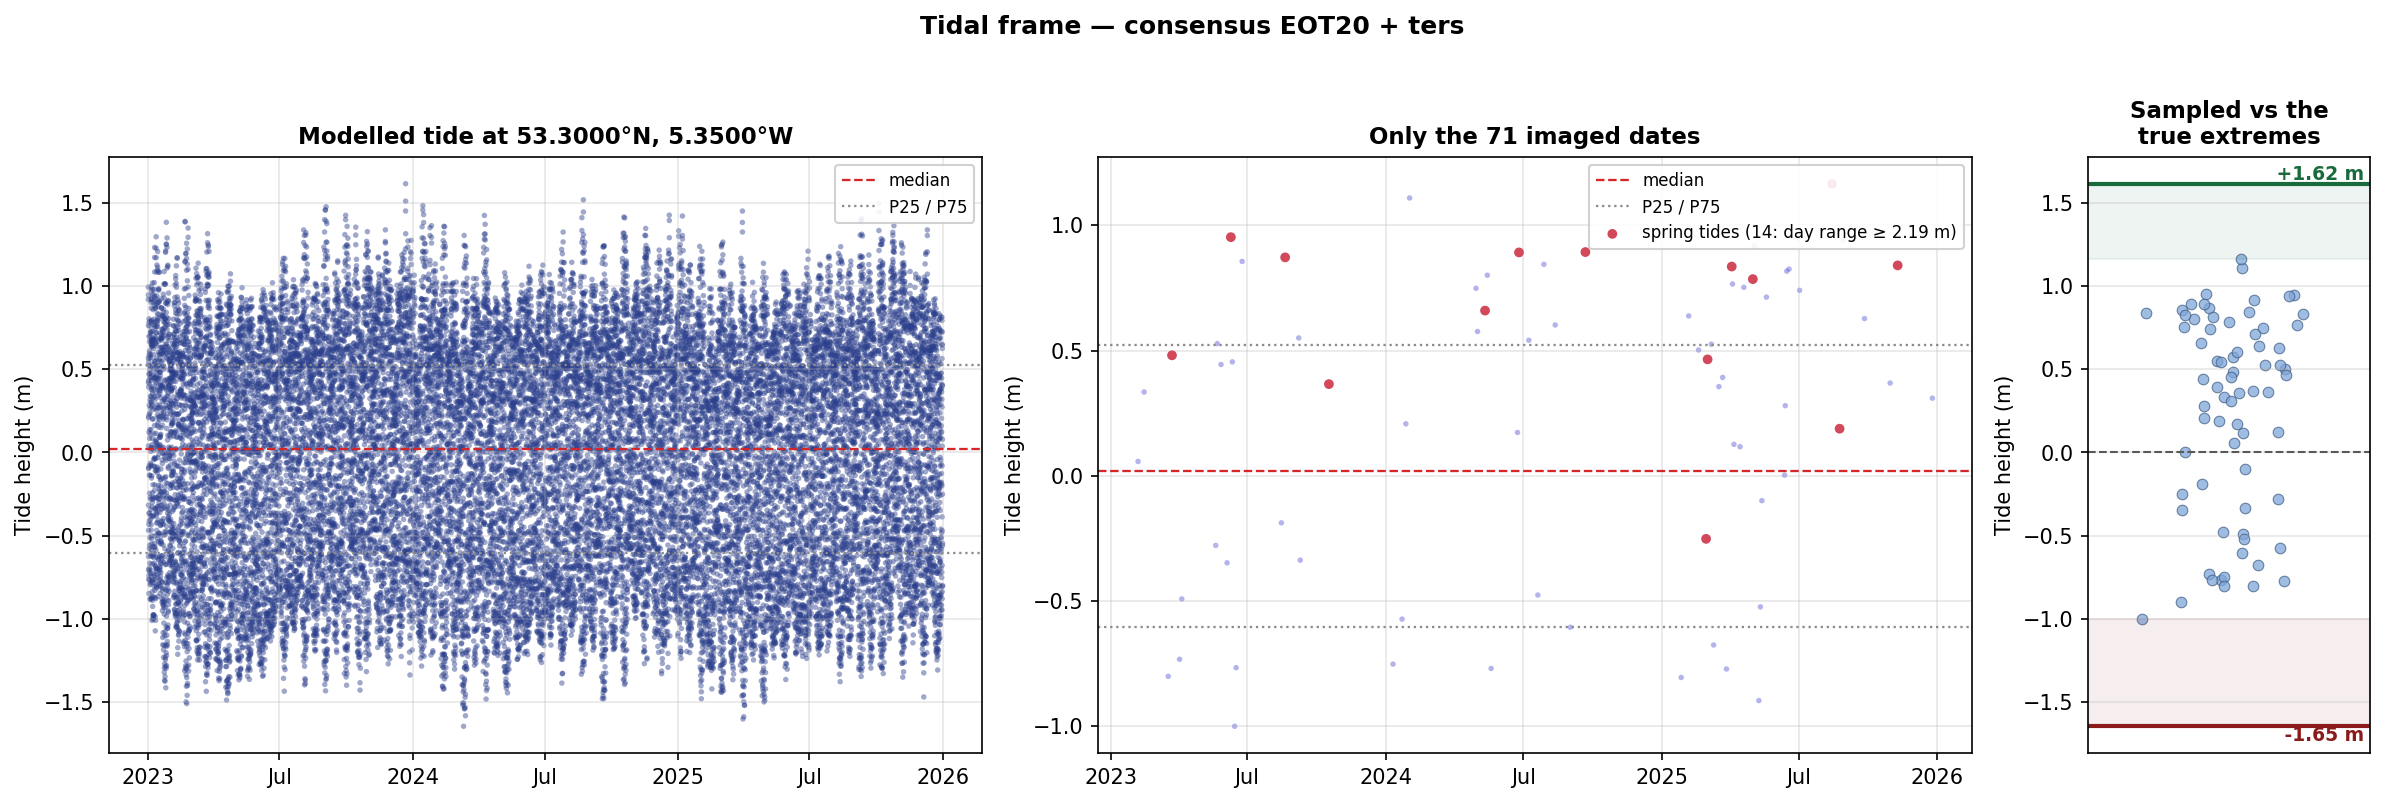

In [9]:
# the catalogue lookup, cached on disk: a Sentinel-2 STAC outage must not
# cost a 40-minute run (it did, twice)
OVERPASS_CACHE = f"{OUT_DIR}/overpass_times.json"
if os.path.exists(OVERPASS_CACHE):
    overpass = {k: pd.Timestamp(v).to_pydatetime() for k, v in
                json.load(open(OVERPASS_CACHE)).items()}
    print(f"overpass times from cache: {len(overpass)} dates")
else:
    overpass = pit.overpass.get_overpass_times(aoi.bbox, TIME_EXTENT, verbose=False)
    json.dump({k: v.isoformat() for k, v in overpass.items()}, open(OVERPASS_CACHE, "w"))
    print(f"overpass times from the catalogue: {len(overpass)} dates (cached)")
record_pool = (usable_dates if SCENE_RULE == "transition" else
               [d for d in cube.dates if TIME_EXTENT[0] <= d <= TIME_EXTENT[1]])
dated = [d for d in record_pool if d in overpass]
t_over = pd.DatetimeIndex(pd.to_datetime([overpass[d] for d in dated])).tz_localize(None)
h_over = np.asarray(boundary.levels(t_over), float)
tide_heights = {d: float(h) for d, h in zip(dated, h_over) if np.isfinite(h)}
print(f"{len(tide_heights)} of {len(usable_dates)} usable dates have an overpass "
      f"time and a finite boundary level")

series_times = grid5[::12]                      # hourly
series_heights = lev5["boundary"][::12]
sampled = np.array(list(tide_heights.values()))
metrics = pit.coverage.coverage_metrics(sampled, series_heights)
verdict = pit.coverage.coverage_verdict(metrics)
pit.coverage.print_coverage_report(metrics, verdict,
                                   title=f"Tidal sampling · {aoi.name}")
sampled_times = pd.to_datetime([overpass[d] for d in sorted(tide_heights)]).tz_localize(None)
sampled = np.array([tide_heights[d] for d in sorted(tide_heights)])
viz.plot_tide_record(series_times, series_heights, sampled_times, sampled,
                     model_name=boundary.name, location=(lat_c, lon_c));
log.record("boundary levels", kind="apply",
           params={"tide_model": TIDE_MODEL, "n_gauges": N_GAUGES,
                   "held_out": JUDGE_GAUGES},
           outputs=[f"{len(tide_heights)} scene levels"])

## 7 · MAREA — the interior clock, measured from the imagery

The binary wet/dry record of every intertidal pixel is extracted once from
all cube scenes (it fixes the pixels and the distance axis). MAREA's record is
then the usable dates of section 3 (the transition-zone cloud screening of the
method) that have an overpass time and a finite boundary level; inside a kept
scene, cloudy pixels are masked by the scene classification. MAREA bands the
flat by geodesic distance from the mouth, fits one clock lag per band against
the boundary (monotone inland, with a scene-bootstrap interval), smooths it to
every pixel and re-inverts every elevation. The "no delay" product is the same
inversion on the same record with the lag set to zero.

In [ ]:
EXTRACT = f"{OUT_DIR}/marea_extract.npz"
if os.path.exists(EXTRACT):
    z_ = np.load(EXTRACT, allow_pickle=True)
    ex = {k: z_[k] for k in z_.files}
    ex["shape"] = tuple(int(v) for v in ex["shape"])
    ex["bbox"] = ex["bbox"].item()
    ex["crs_wkt"] = str(ex["crs_wkt"])
    print(f"loaded {EXTRACT}")
else:
    ex = marea.extract(cube.cache_path)
    seeds = pit.geometry.mouth_seeds(ex["sea"])
    s_m = pit.geometry.along_distance(ex["sea"] | ex["inter"], seeds, RESOLUTION_M)
    ex["s_km"] = (s_m.ravel()[ex["keep"]] / 1000.0).astype(np.float32)
    np.savez_compressed(EXTRACT, Y=ex["Y"], C=ex["C"], keep=ex["keep"],
                        dates=ex["dates"], shape=np.array(ex["shape"]),
                        sea=ex["sea"], inter=ex["inter"], s_km=ex["s_km"],
                        bbox=np.array(ex["bbox"], dtype=object),
                        crs_wkt=np.array(ex["crs_wkt"]))
    print(f"extracted and saved {EXTRACT}")
keep = ex["keep"]
assert ex["shape"] == (H, W), "extraction grid differs from the cube grid"
# distance from the mouth, measured from the sea on MOUTH_SIDE only, and
# written back so the background job shares it
s_old = ex.get("s_km")
seeds = pit.geometry.mouth_seeds(ex["sea"], side=MOUTH_SIDE)
s_m = pit.geometry.along_distance(ex["sea"] | ex["inter"], seeds, RESOLUTION_M)
ex["s_km"] = (s_m.ravel()[keep] / 1000.0).astype(np.float32)
s_km = ex["s_km"].astype(float)
# rewrite the (large) extraction only when the distance axis changed
if s_old is None or not np.array_equal(np.asarray(s_old, np.float32), ex["s_km"], equal_nan=True):
    np.savez_compressed(EXTRACT, Y=ex["Y"], C=ex["C"], keep=keep, dates=ex["dates"],
                        shape=np.array(ex["shape"]), sea=ex["sea"], inter=ex["inter"],
                        s_km=ex["s_km"], bbox=np.array(ex["bbox"], dtype=object),
                        crs_wkt=np.array(ex["crs_wkt"]))
    print(f"distance axis updated -> rewrote {EXTRACT}")
print(f"{len(keep):,} intertidal px in the record "
      f"(pipeline mask above: {int(intertidal.sum()):,}); "
      f"s from the {MOUTH_SIDE} mouth up to {np.nanmax(s_km):.1f} km "
      f"({np.isnan(s_km).mean():.0%} hydraulically isolated px, no s)")

# the record: the method's transition-zone scene rule (usable dates of cell 12)
# ∩ an overpass time ∩ a finite boundary level (cell 17's tide_heights)
rec = np.array([d in tide_heights for d in ex["dates"]])
ex_rec = {**ex, "Y": ex["Y"][rec], "C": ex["C"][rec], "dates": ex["dates"][rec]}
print(f"MAREA record: {int(rec.sum())} of {len(rec)} cube scenes "
      f"(transition-zone rule, overpass time, finite boundary level)")

t0 = time.time()
marea_res = marea.reconstruct(cube.cache_path, out_dir=f"{OUT_DIR}/marea_{BOUNDARY_TAG}",
                              name=aoi.name, pixel_m=RESOLUTION_M,
                              boundary=boundary, extraction=ex_rec,
                              mouth_side=MOUTH_SIDE, min_scenes=MIN_SCENES,
                              overpass_times=overpass)
assert marea_res is not None and marea_res["estado"] == "ok", "reconstruct refused the record"
assert marea_res["n_escenas"] == int(rec.sum()), "the overpass lookup dropped record scenes"
print(f"\nscenes in the MAREA record: {marea_res['n_escenas']}")
print(f"pixels inverted: {marea_res['n_px_cota']:,} / {marea_res['n_px']:,}")
print(f"interior tide adopted: {marea_res['con_operador']}  "
      f"(physics veto: {marea_res['veto_fisico']})  [{time.time() - t0:.0f} s]")
mp = np.load(f"{OUT_DIR}/marea_{BOUNDARY_TAG}/marea.npz")
band_of, centres = mp["band"].astype(int), np.asarray(marea_res["centros_km"])
tau_fit, tau_used = np.asarray(marea_res["tau_min"]), np.asarray(marea_res["tau_usado_min"])
tau_lo, tau_hi = np.asarray(marea_res["tau_lo_min"]), np.asarray(marea_res["tau_hi_min"])
tau_px = mp["tau_px_min"].astype(float)          # the lag every pixel received
BAND_KM = float(mp["band_km"][0])
print(f"{len(centres)} bands of {BAND_KM:.0f} km; lag per band (min): {np.round(tau_used, 0)}")
print(f"95 % bootstrap intervals ({marea_res['n_boot']} scene resamples): "
      + ", ".join(f"[{a:+.0f}, {b:+.0f}]" for a, b in zip(tau_lo, tau_hi)))

s_grid = np.linspace(0, float(np.nanmax(s_km)), 200)
tau_curve = te.smooth_lag_profile(centres, tau_used, s_grid, bandwidth_km=BAND_KM)
plt.figure(figsize=(7.5, 4.2))
plt.errorbar(centres, tau_used, yerr=[np.clip(tau_used - tau_lo, 0, None), np.clip(tau_hi - tau_used, 0, None)],
             fmt="o", color="#1a76b3", capsize=4, label="lag per band (95 % bootstrap interval)")
plt.plot(s_grid, tau_curve, "-", color="crimson", lw=2, label=f"lag applied per pixel (kernel {BAND_KM:.0f} km)")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("distance from the mouth  s  (km)"); plt.ylabel("cotidal lag  (min)")
plt.title(f"MAREA clocks · boundary = {boundary.name}"); plt.legend(); plt.grid(alpha=0.3);
log.record("MAREA clocks", kind="fit", params={"n_bands": len(centres)},
           inputs=["wet/dry record", "boundary"],
           outputs=[f"tau per band: {np.round(tau_used, 0).tolist()} min"])

## 8 · Bathymetry without vs with the MAREA adjustment

**Same pixels, same scenes, same inversion.** The plain product reads the
boundary at the overpass time; the MAREA product reads it τ minutes earlier
in each band where τ was detected. The elevation grid (`lo`, `hi`) is shared,
so the two maps differ only through the clock.

In [ ]:
times_all = overpass                    # the catalogue lookup of section 6, reused
have = rec.copy()                       # the MAREA record of cell 19 (transition-zone rule)
t_real = pd.DatetimeIndex(pd.to_datetime([times_all[d] for d in ex["dates"][have]])).tz_localize(None)
Y = np.nan_to_num(ex["Y"][have], nan=0.0).astype(np.float32)
C = ex["C"][have].astype(np.float32)
h0 = np.asarray(boundary.levels(t_real), float)
okh = np.isfinite(h0)
Y, C, t_real, h0 = Y[okh], C[okh], t_real[okh], h0[okh]
lo, hi = float(h0.min()), float(h0.max())
assert len(t_real) == marea_res["n_escenas"] and np.allclose([lo, hi], marea_res["rango_marea_m"]), \
    "the inversion record differs from the lag fit's record"
print(f"record: {len(t_real)} scenes × {Y.shape[1]:,} px; level grid [{lo:+.2f}, {hi:+.2f}] m")

def to_raster(vals):
    r = np.full(H * W, np.nan, np.float32); r[keep] = vals
    return r.reshape(H, W)

t0 = time.time()
z_plain, sg_plain = marea.invert_series(Y, C, h0, lo, hi, min_bracket=marea.QUALITY_MIN_BRACKET)
print(f"plain inversion: {int(np.isfinite(z_plain).sum()):,} px  [{time.time() - t0:.0f} s]")

# every pixel is inverted with the level series read tau_px minutes
# earlier, tau_px being the smoothed band profile at the pixel's own s;
# pixels sharing a (whole-minute) lag share the shifted series
z_marea = np.full(len(keep), np.nan)
for tv in np.unique(tau_px):
    cols = np.flatnonzero(tau_px == tv)
    h_k = (np.asarray(boundary.levels(t_real - pd.Timedelta(minutes=float(tv))), float)
           if tv else h0)
    z_marea[cols], _ = marea.invert_series(Y[:, cols], C[:, cols], h_k, lo, hi, min_bracket=marea.QUALITY_MIN_BRACKET)
print(f"MAREA inversion: {int(np.isfinite(z_marea).sum()):,} px, "
      f"{len(np.unique(tau_px))} distinct lags  [{time.time() - t0:.0f} s]")
# no detection threshold any more: the fitted profile IS the applied one;
# the alias keeps the downstream cells of this notebook unchanged
z_marea_fit = z_marea.copy()
# the shipped MAREA product used the identical call → it must agree
z_ship = mp["z"].astype(float)
m = np.isfinite(z_ship) & np.isfinite(z_marea)
dd = np.abs(z_ship[m] - z_marea[m])
print(f"agreement with the shipped product: median |Δ| = {np.median(dd):.3f} m, "
      f"p95 {np.percentile(dd, 95):.3f} m, {np.mean(dd > 0.05):.1%} of px differ by > 5 cm")

dem_plain, dem_marea, dem_fit = to_raster(z_plain), to_raster(z_marea), to_raster(z_marea_fit)
fig, axes = plt.subplots(2, 2, figsize=(19, 13))
viz.plot_dem(dem_plain, transform, crs, aoi, title="Without adjustment (boundary at overpass time)", ax=axes[0, 0])
viz.plot_dem(dem_marea, transform, crs, aoi, title="With MAREA clocks (applied product)", ax=axes[0, 1])
viz.plot_map(dem_marea - dem_plain, transform, crs, aoi, cmap="RdBu_r", vmin=-0.3, vmax=0.3,
             robust=False, hillshade=False, title="applied MAREA − plain (m)", cbar_label="Δz (m)", ax=axes[1, 0])
viz.plot_map(to_raster(tau_px), transform, crs, aoi, cmap="magma", vmin=0, vmax=max(1.0, float(tau_px.max())),
             robust=False, hillshade=False, title="lag applied to each pixel (min)", cbar_label="τ (min)", ax=axes[1, 1])
fig.tight_layout();

,band,s_km,tau_fitted_min,tau_applied_min,n_px,median_dz_m,p10_dz_m,p90_dz_m
0,0,1.65,0.0,0.000,19620,0.051,-0.101,0.203
1,1,4.82,54.2,54.199,42202,0.152,-0.253,0.506
2,2,7.56,78.9,78.858,53344,0.253,-0.355,0.709
3,3,10.31,86.4,86.383,52890,0.405,0.000,0.810
4,4,13.22,96.3,96.272,32832,0.355,-0.355,0.810
5,5,16.94,127.6,127.639,32027,0.000,-0.861,0.962
6,6,19.44,132.6,132.625,52640,0.861,-0.152,1.368
7,7,21.77,141.6,141.553,21471,0.861,0.152,1.216


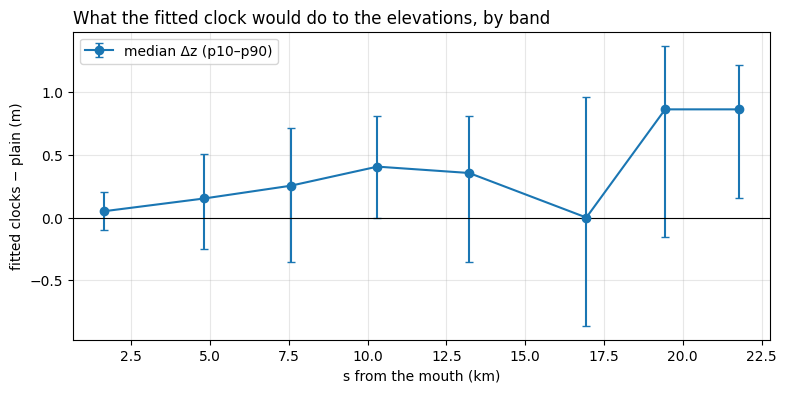

In [12]:
# where the clock acts: the difference by band of distance from the mouth
# (the fitted clocks, so the table says something even when the applied
# product keeps the boundary's clock everywhere)
d = z_marea_fit - z_plain
rows_ = []
for k in range(len(centres)):
    sel = (band_of == k) & np.isfinite(d)
    rows_.append({"band": k, "s_km": round(float(centres[k]), 2),
                  "tau_fitted_min": round(float(tau_fit[k]), 1),
                  "tau_applied_min": float(tau_used[k]), "n_px": int(sel.sum()),
                  "median_dz_m": float(np.median(d[sel])) if sel.any() else np.nan,
                  "p10_dz_m": float(np.percentile(d[sel], 10)) if sel.any() else np.nan,
                  "p90_dz_m": float(np.percentile(d[sel], 90)) if sel.any() else np.nan})
band_table = pd.DataFrame(rows_)
display(band_table.round(3))
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(band_table.s_km, band_table.median_dz_m,
            yerr=[band_table.median_dz_m - band_table.p10_dz_m, band_table.p90_dz_m - band_table.median_dz_m],
            fmt="o-", color="#1a76b3", capsize=3, label="median Δz (p10–p90)")
ax.axhline(0, color="k", lw=0.8); ax.set_xlabel("s from the mouth (km)"); ax.set_ylabel("fitted clocks − plain (m)")
ax.set_title("What the fitted clock would do to the elevations, by band", loc="left"); ax.grid(alpha=0.3); ax.legend();

## 9 · MAREA vs Granadeiro

Granadeiro's product is the faithful reimplementation in
`experiments/sota_granadeiro.py` (inter-calibration on sea/land pixels,
Eq. 1 cosine heights between the boundary's extremes, per-pixel logistic on
standardised NIR, rising/ebbing lag sample, thin-plate-spline lag map,
Eq. 5 exposure), run under **this notebook's boundary** by
`experiments/e0_escalda_prep.py` (hours, so it is a background job — the
declared substitutions are in the script's header).

Three products are compared:

* **MAREA** — our clock, our estimator (section 8);
* **Granadeiro** — their clock, their estimator;
* **crossed** — their lag map, our inversion. If the crossed row sits with
  MAREA, the clocks agree and the estimator makes the difference; if it sits
  with Granadeiro, the clock does.

loaded products_wadden/granadeiro_products_2023-2025_eot20_g1.npz: 66,757 px converged; lag map median +33 min, range [-239, +122]; 985 lag samples

Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

...

Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

crossed inversion: 308,614 px  [794 s]

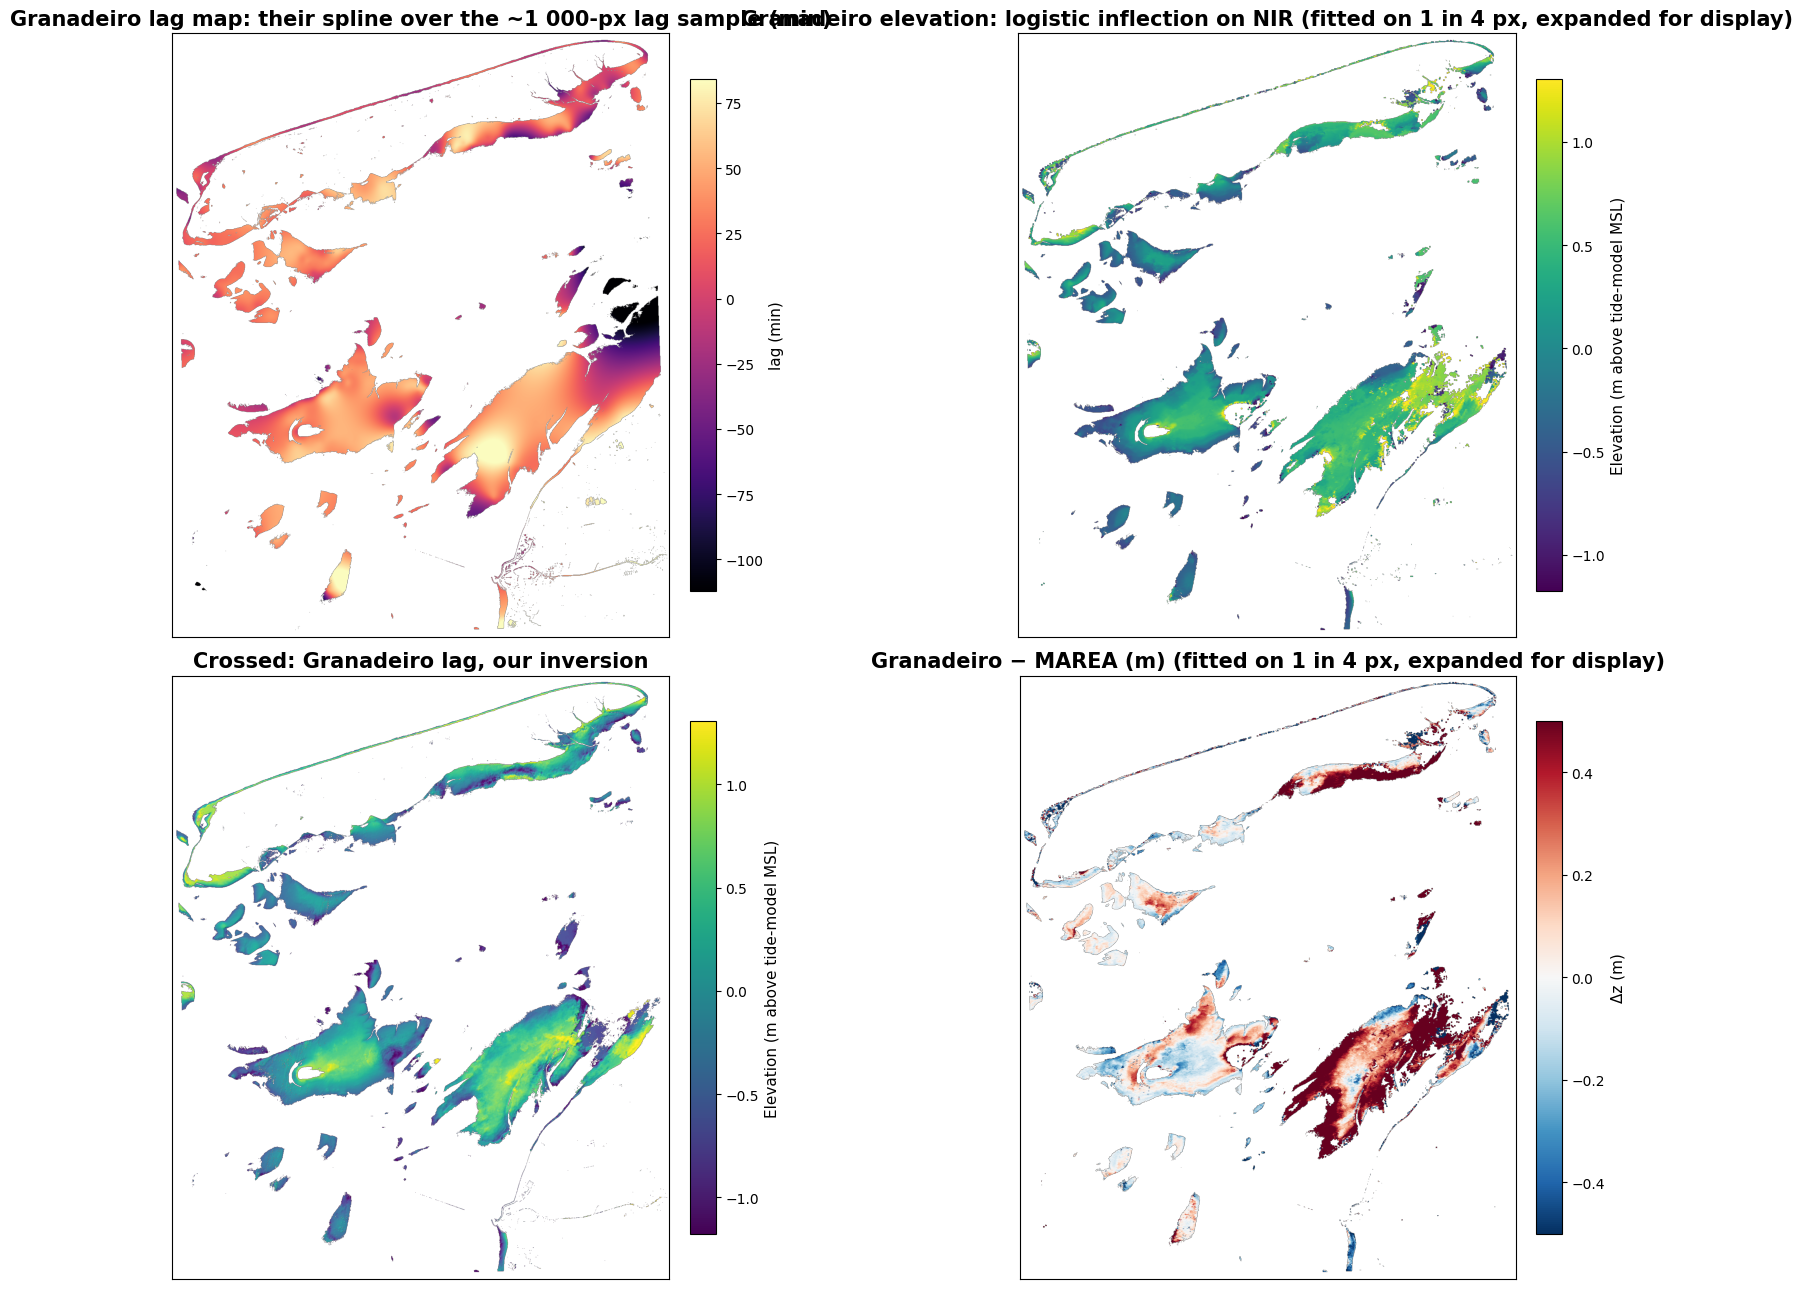

In [13]:
GRAN = f"{OUT_DIR}/granadeiro_products_2023-2025_{BOUNDARY_TAG}.npz"
gran = None
if os.path.exists(GRAN):
    gran = np.load(GRAN, allow_pickle=True)
    assert np.array_equal(gran["keep"], keep), "Granadeiro product is on other pixels"
    z_gran, lag_all = gran["final"].astype(float), gran["lag_all"].astype(float)
    mp_z_for_diff = z_marea
    print(f"loaded {GRAN}: {int(np.isfinite(z_gran).sum()):,} px converged; "
          f"lag map median {np.median(lag_all):+.0f} min, range "
          f"[{lag_all.min():+.0f}, {lag_all.max():+.0f}]; "
          f"{int(np.isfinite(gran['lag_sample']).sum())} lag samples")
    # crossed: their per-pixel lag, our inversion (lags quantised to 5 min)
    t0 = time.time()
    z_cross = np.full(len(keep), np.nan)
    lag_q = np.round(lag_all / 5.0) * 5.0
    for lq in np.unique(lag_q):
        cols = np.flatnonzero(lag_q == lq)
        h_q = np.asarray(boundary.levels(t_real - pd.Timedelta(minutes=float(lq))), float)
        z_cross[cols], _ = marea.invert_series(Y[:, cols], C[:, cols], h_q, lo, hi)
    print(f"crossed inversion: {int(np.isfinite(z_cross).sum()):,} px  [{time.time() - t0:.0f} s]")
    dem_gran, dem_cross, lag_map = to_raster(z_gran), to_raster(z_cross), to_raster(lag_all)
    # Granadeiro was fitted on every k-th pixel (px_stride) on the large
    # flats: a 1-in-4 lattice renders as grey under a hillshade because three
    # pixels in four are empty. For DISPLAY ONLY each fitted pixel is painted
    # over its k x k block, inside the intertidal record; the numbers above
    # use the fitted pixels alone.
    fitted = np.isfinite(z_gran)
    stride = int(round(1.0 / max(fitted.mean(), 1e-6))) if fitted.mean() < 0.6 else 1
    stride = int(np.clip(stride, 1, 4))
    def expand(vals):
        r = to_raster(vals)
        if stride == 1:
            return r
        out = np.full_like(r, np.nan)
        rr_, cc_ = keep // W, keep % W
        ok_ = np.isfinite(vals)
        rec = np.zeros((H, W), bool); rec[rr_, cc_] = True
        for dr in range(stride):
            for dc in range(stride):
                r2, c2 = np.clip(rr_[ok_] + dr, 0, H - 1), np.clip(cc_[ok_] + dc, 0, W - 1)
                paint = rec[r2, c2] & ~np.isfinite(out[r2, c2])
                out[r2[paint], c2[paint]] = vals[ok_][paint]
        return out
    note = f" (fitted on 1 in {stride} px, expanded for display)" if stride > 1 else ""
    fig, axes = plt.subplots(2, 2, figsize=(19, 13))
    viz.plot_map(lag_map, transform, crs, aoi, cmap="magma", robust=True, hillshade=False,
                 title="Granadeiro lag map: their spline over the ~1 000-px lag sample (min)", cbar_label="lag (min)", ax=axes[0, 0])
    viz.plot_map(expand(z_gran), transform, crs, aoi, cmap="viridis", robust=False, hillshade=False,
                 vmin=float(np.nanmin(dem_marea)), vmax=float(np.nanmax(dem_marea)),
                 title="Granadeiro elevation: logistic inflection on NIR" + note, cbar_label="Elevation (m above tide-model MSL)", ax=axes[0, 1])
    viz.plot_dem(dem_cross, transform, crs, aoi, title="Crossed: Granadeiro lag, our inversion", ax=axes[1, 0])
    viz.plot_map(expand(z_gran - mp_z_for_diff), transform, crs, aoi, cmap="RdBu_r", vmin=-0.5, vmax=0.5,
                 robust=False, hillshade=False, title="Granadeiro − MAREA (m)" + note, cbar_label="Δz (m)", ax=axes[1, 1])
    fig.tight_layout()
else:
    print(f"{GRAN} not found — run:  python -m experiments.e0_escalda_prep "
          f"{TIDE_MODEL or 'none'} {N_GAUGES or 'none'}   (hours; background)")

common subset: 60,763 px

,product,n_px,median offset vs MAREA (m),"spread vs MAREA, IQR (m)",RMS vs MAREA after centring (m),corr with MAREA
0,plain (no clock),308458,-0.304,0.608,0.499,0.439
1,MAREA,359815,0.000,0.000,0.000,1.000
2,"crossed (their lag, our inversion)",308614,0.000,0.203,0.352,0.731
3,Granadeiro,66757,0.043,0.349,0.404,0.602


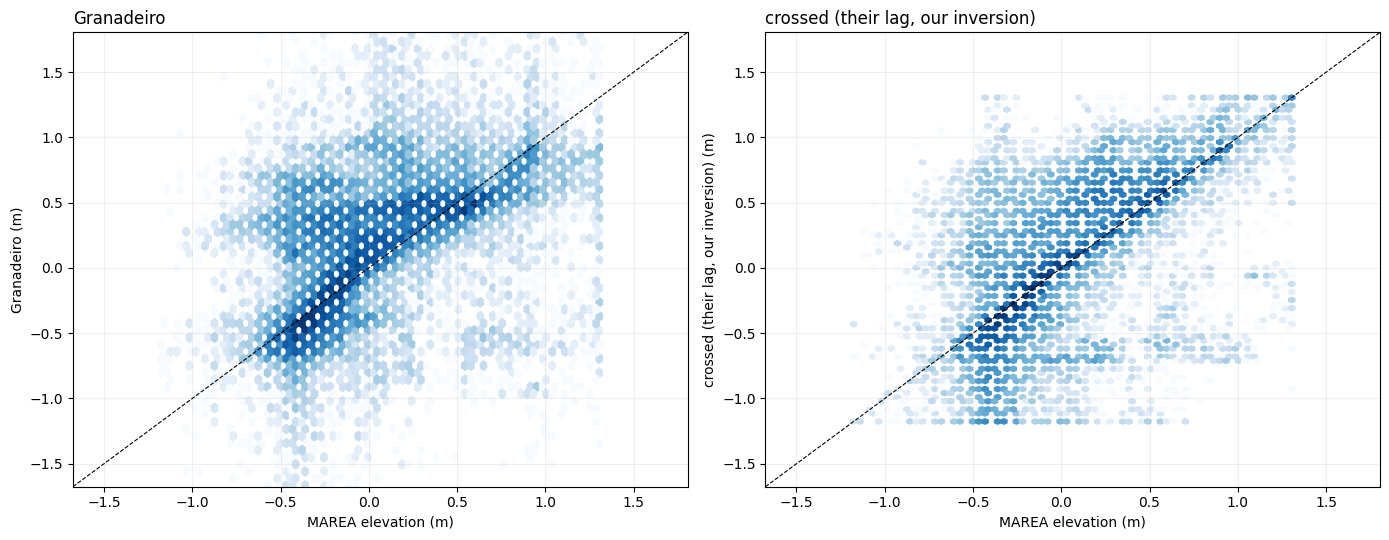

In [14]:
if gran is not None:
    prods = {"plain (no clock)": z_plain, "MAREA": z_marea,
             "crossed (their lag, our inversion)": z_cross, "Granadeiro": z_gran}
    common = np.ones(len(keep), bool)
    for v in prods.values():
        common &= np.isfinite(v)
    ref = z_marea[common]
    rows_ = []
    for k, v in prods.items():
        dv = v[common] - ref
        rows_.append({"product": k, "n_px": int(np.isfinite(v).sum()),
                      "median offset vs MAREA (m)": float(np.median(dv)),
                      "spread vs MAREA, IQR (m)": float(np.subtract(*np.percentile(dv, [75, 25]))),
                      "RMS vs MAREA after centring (m)": float(np.sqrt(np.mean((dv - np.median(dv)) ** 2))),
                      "corr with MAREA": float(np.corrcoef(v[common], ref)[0, 1])})
    print(f"common subset: {int(common.sum()):,} px")
    display(pd.DataFrame(rows_).round(3))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    for ax, (k, v) in zip(axes, [("Granadeiro", z_gran), ("crossed (their lag, our inversion)", z_cross)]):
        ax.hexbin(ref, v[common], gridsize=70, bins="log", cmap="Blues")
        lim = (lo - 0.5, hi + 0.5); ax.plot(lim, lim, "k--", lw=0.8); ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel("MAREA elevation (m)"); ax.set_ylabel(f"{k} (m)"); ax.set_title(k, loc="left"); ax.grid(alpha=0.2)
    fig.tight_layout()

## 10 · Validation of the lag: the gauge pair

The site has a gauge near the mouth and one inside, the judge. Three things
are measured from the two records and compared with MAREA, **with and
without the lag applied**:

1. **the lag between the two gauges in reaching the same level** — for a
   level h and a limb (rising or falling), the time the inner gauge crosses
   h minus the time the mouth gauge crossed it, cycle by cycle over the
   period; taken at the 25th, 50th and 75th percentile of the mouth's level.
   It is compared with the lag MAREA measured between band 0 (where the
   mouth gauge is) and the band that contains the judge, and with no delay;
2. **the difference in level between the two gauges at the same instant**
   — the error of assuming one uniform level over the estuary;
3. **the error of the predicted level at the judge** — the boundary read
   τ minutes earlier against the judge's own record, with τ = 0 (no delay)
   and with τ = the lag MAREA assigns at the judge's distance from the
   mouth. The RMSE is median-centred (a gauge datum is not the boundary
   datum) and, because nothing was fitted on the judge, the whole period is
   the test window.

Both records are demeaned first: their zeros are different datums.

mouth gauge ters (Terschelling Noordzee), inner gauge harl (Harlingen) at s = 18.3 km, MAREA band 6; MAREA lag at the judge's distance +128.8 min

,level_m,limb,n,lag_mean_min,lag_median_min,lag_std_min
0,-0.59,rising,1738,96.88,97.42,8.71
1,-0.59,falling,1731,102.34,104.47,25.72
2,0.07,rising,1938,93.58,96.16,20.88
3,0.07,falling,1936,80.72,82.47,23.37
4,0.59,rising,1548,82.37,89.21,35.22
5,0.59,falling,1534,71.31,71.56,21.85


,quantity,value
0,"gauge-to-gauge lag, all levels and limbs (min)",88.3
1,"gauge-to-gauge lag, rising limb (min)",91.4
2,"gauge-to-gauge lag, falling limb (min)",85.1
3,"MAREA lag, band 0 to band 6 (min)",132.6
4,"MAREA lag, 95 % bootstrap interval of band 6 (...","[+123, +138]"
5,"MAREA lag at the judge's distance, smoothed pr...",128.8
6,no delay (min),0.0
7,"same-instant level difference inner − mouth, R...",0.529
8,"same-instant level difference inner − mouth, m...",-0.001
9,"same-instant level difference, p05 / p95 (m)",-0.98 / +0.66


level error at Harlingen (median-centred RMSE, whole period):

,method,lag at the judge (min),RMSE at the judge (m),n
0,no delay,0.0,0.5624,147651
1,MAREA,128.8,0.3026,147638


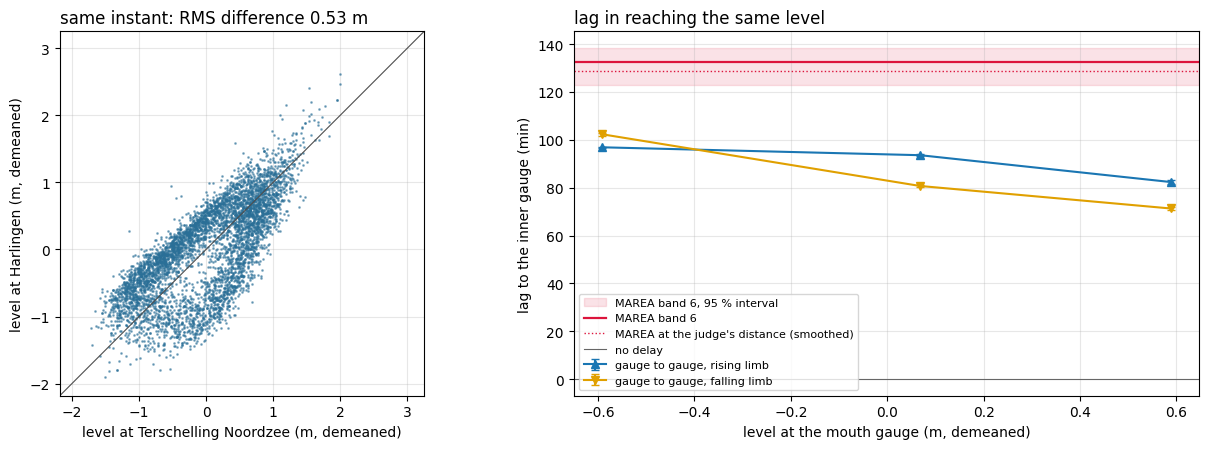

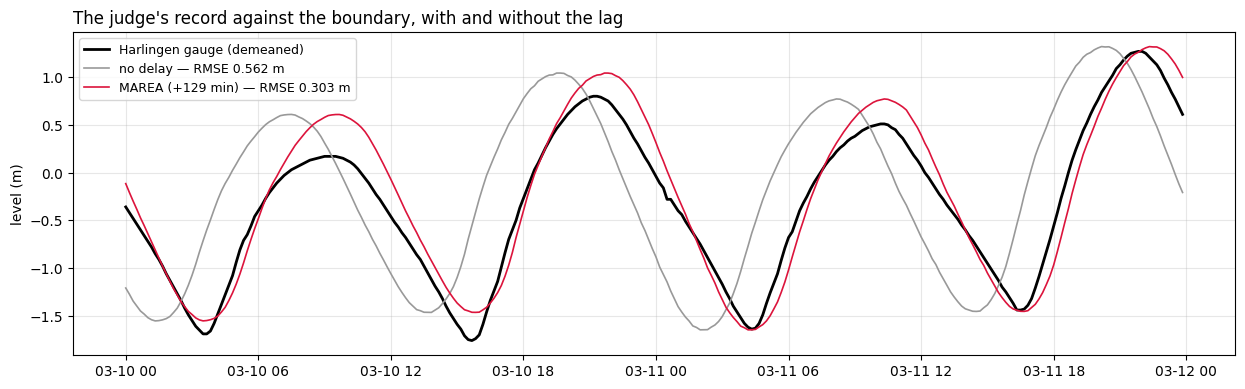

In [15]:
from pyintertidal import lag_validation as lv
import pyproj
fwd = pyproj.Transformer.from_crs("EPSG:4326", crs, always_xy=True)
rows_k, cols_k = keep // W, keep % W

def gauge_axis_position(code_):
    st = stations[code_]
    x, y = fwd.transform(float(st["Lon"]), float(st["Lat"]))
    col, row = ~transform * (x, y)
    dpx = np.hypot(rows_k - row, cols_k - col)
    nearest = np.argsort(dpx)[:200]                 # the 200 nearest intertidal px
    return float(np.nanmedian(s_km[nearest])), nearest, float(dpx[nearest].max() * RESOLUTION_M / 1000)

judges = [c for c in JUDGE_GAUGES if c in stations]
jc = judges[0]
mouth_code = min(member_codes, key=lambda c: gauge_axis_position(c)[0])
s_j, near_px, _ = gauge_axis_position(jc)
k_j = int(np.bincount(band_of[near_px][band_of[near_px] >= 0]).argmax())
tau_marea = float(te.smooth_lag_profile(centres, tau_used, np.array([s_j]), bandwidth_km=BAND_KM)[0])
print(f"mouth gauge {mouth_code} ({stations[mouth_code]['Location']}), inner gauge {jc} "
      f"({stations[jc]['Location']}) at s = {s_j:.1f} km, MAREA band {k_j}; "
      f"MAREA lag at the judge's distance {tau_marea:+.1f} min")

# (1) the lag between the gauges in reaching the same level, by limb
mouth_s, inner_s = lv.gauge_series(mouth_code), lv.gauge_series(jc)
levels_q = [float(mouth_s.quantile(q)) for q in (0.25, 0.50, 0.75)]
lag_table, per_cycle = lv.level_crossing_lags(mouth_s, inner_s, levels_q)
w_ = lag_table["n"].to_numpy(float)
gauge_lag = float(np.sum(w_ * lag_table["lag_mean_min"].to_numpy()) / w_.sum())
lag_rise = lag_table[lag_table.limb == "rising"]; lag_fall = lag_table[lag_table.limb == "falling"]
gauge_lag_rise = float(np.average(lag_rise.lag_mean_min, weights=lag_rise.n))
gauge_lag_fall = float(np.average(lag_fall.lag_mean_min, weights=lag_fall.n))
display(lag_table.round(2))

# (2) the level difference between the gauges at the same instant
diff_series, diff_stats = lv.same_instant_difference(mouth_s, inner_s)

pair_rows = [
    {"quantity": "gauge-to-gauge lag, all levels and limbs (min)", "value": round(gauge_lag, 1)},
    {"quantity": "gauge-to-gauge lag, rising limb (min)", "value": round(gauge_lag_rise, 1)},
    {"quantity": "gauge-to-gauge lag, falling limb (min)", "value": round(gauge_lag_fall, 1)},
    {"quantity": f"MAREA lag, band 0 to band {k_j} (min)", "value": round(float(tau_used[k_j]), 1)},
    {"quantity": f"MAREA lag, 95 % bootstrap interval of band {k_j} (min)", "value": f"[{tau_lo[k_j]:+.0f}, {tau_hi[k_j]:+.0f}]"},
    {"quantity": "MAREA lag at the judge's distance, smoothed profile (min)", "value": round(float(tau_marea), 1)},
    {"quantity": "no delay (min)", "value": 0.0},
    {"quantity": "same-instant level difference inner − mouth, RMS (m)", "value": round(diff_stats["rms_m"], 3)},
    {"quantity": "same-instant level difference inner − mouth, mean (m)", "value": round(diff_stats["mean_m"], 3)},
    {"quantity": "same-instant level difference, p05 / p95 (m)", "value": f"{diff_stats['p05_m']:+.2f} / {diff_stats['p95_m']:+.2f}"},
    {"quantity": "10-min samples with both gauges", "value": diff_stats["n"]},
]
pair_table = pd.DataFrame(pair_rows)
display(pair_table)

# (3) the level error at the judge, with and without the lag applied
grid10 = pd.date_range(TIME_EXTENT[0], pd.Timestamp(TIME_EXTENT[1]) + pd.Timedelta(days=1), freq="10min")
tg = grid10.values.astype("int64") / 1e9
t5 = grid5.values.astype("int64") / 1e9

def gauge_truth(code_):
    df = load_cached_ioc(code_)
    df = despike(df[(df["time"] >= TIME_EXTENT[0]) & (df["time"] <= TIME_EXTENT[1])])
    s_ = pd.Series(df["level_m"].to_numpy(float), index=pd.DatetimeIndex(df["time"]))
    s_ = s_[~s_.index.duplicated()].sort_index()
    v = s_.reindex(grid10, method="nearest", tolerance=pd.Timedelta("10min")).to_numpy(float)
    return v - np.nanmedian(v)

def shifted(levels5, tau_min):
    return np.interp(tg - 60.0 * tau_min, t5, levels5, left=np.nan, right=np.nan)

def rmse_centred(pred, truth):
    m = np.isfinite(pred) & np.isfinite(truth)
    d = pred[m] - truth[m]
    return float(np.sqrt(np.mean((d - np.median(d)) ** 2))), int(m.sum())

truth = gauge_truth(jc)
judge_rows = []
for name, tv in (("no delay", 0.0), ("MAREA", tau_marea)):
    r_, n_ = rmse_centred(shifted(lev5["boundary"], tv), truth)
    judge_rows.append({"method": name, "lag at the judge (min)": round(tv, 1),
                       "RMSE at the judge (m)": r_, "n": n_})
judge_table = pd.DataFrame(judge_rows)
print(f"level error at {stations[jc]['Location']} (median-centred RMSE, whole period):")
display(judge_table.round(4))

fig, axs = plt.subplots(1, 2, figsize=(13, 4.6))
both_ = pd.concat([mouth_s.rename("mouth"), inner_s.rename("inner")], axis=1).dropna()
sub_ = both_.iloc[:: max(1, len(both_) // 5000)]
axs[0].plot(sub_["mouth"], sub_["inner"], ".", ms=2, color="#2a6f97", alpha=0.5)
lim_ = [float(both_.min().min()) - 0.2, float(both_.max().max()) + 0.2]
axs[0].plot(lim_, lim_, "-", color="0.3", lw=0.8)
axs[0].set_xlim(lim_); axs[0].set_ylim(lim_); axs[0].set_aspect("equal")
axs[0].set_xlabel(f"level at {stations[mouth_code]['Location']} (m, demeaned)")
axs[0].set_ylabel(f"level at {stations[jc]['Location']} (m, demeaned)")
axs[0].set_title(f"same instant: RMS difference {diff_stats['rms_m']:.2f} m", loc="left")
axs[0].grid(alpha=0.3)
for limb_, col_, mk_ in (("rising", "#1a76b3", "^"), ("falling", "#e0a000", "v")):
    t_ = lag_table[lag_table.limb == limb_]
    axs[1].errorbar(t_.level_m, t_.lag_mean_min, yerr=t_.lag_std_min / np.sqrt(t_.n.clip(lower=1)),
                    fmt=mk_ + "-", color=col_, capsize=3, label=f"gauge to gauge, {limb_} limb")
axs[1].axhspan(float(tau_lo[k_j]), float(tau_hi[k_j]), color="crimson", alpha=0.12, label=f"MAREA band {k_j}, 95 % interval")
axs[1].axhline(float(tau_used[k_j]), color="crimson", lw=1.6, label=f"MAREA band {k_j}")
axs[1].axhline(float(tau_marea), color="crimson", lw=1.0, ls=":", label="MAREA at the judge's distance (smoothed)")
axs[1].axhline(0, color="0.4", lw=0.8, label="no delay")
axs[1].set_xlabel("level at the mouth gauge (m, demeaned)"); axs[1].set_ylabel("lag to the inner gauge (min)")
axs[1].set_title("lag in reaching the same level", loc="left"); axs[1].grid(alpha=0.3); axs[1].legend(fontsize=8)
fig.tight_layout()

# one window at the judge: the record, and the boundary with and without the lag
win = (grid10 >= d0) & (grid10 < d0 + pd.Timedelta(days=2))
fig, ax = plt.subplots(figsize=(15, 4.2))
ax.plot(grid10[win], truth[win], "k", lw=2, label=f"{stations[jc]['Location']} gauge (demeaned)")
ax.plot(grid10[win], shifted(lev5["boundary"], 0.0)[win], color="#999", lw=1.2,
        label=f"no delay — RMSE {judge_rows[0]['RMSE at the judge (m)']:.3f} m")
ax.plot(grid10[win], shifted(lev5["boundary"], tau_marea)[win], color="crimson", lw=1.2,
        label=f"MAREA ({tau_marea:+.0f} min) — RMSE {judge_rows[1]['RMSE at the judge (m)']:.3f} m")
ax.set_ylabel("level (m)"); ax.grid(alpha=0.3); ax.legend(fontsize=9)
ax.set_title("The judge's record against the boundary, with and without the lag", loc="left")

os.makedirs(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}", exist_ok=True)
lag_table.to_csv(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/lag_pair_by_level.csv", index=False)
pair_table.to_csv(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/lag_pair_metrics.csv", index=False)
judge_table.to_csv(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/judge_metrics.csv", index=False)

## 10b · Validation of the elevation: the external reference

Three products against the external elevation reference of the site, on the
intertidal pixels each resolves and on the pixels all three resolve:
**no delay**, **MAREA** and **Granadeiro**. Median-centred RMSE (a survey
datum is not the boundary datum; the offset is reported apart as the bias)
and the OLS slope of the product on the reference (1 when the map
reproduces the relief, below 1 when it compresses it).

* **Spanish sites** — the IGN 5 m LiDAR DTM (PNOA), reprojected onto the
  product grid. A LiDAR flown at high water returns the water surface over
  the flats, one value repeated everywhere, so the reference's own
  behaviour is reported first: the modal value over the intertidal mask and
  the share of cells within 5 cm of it.
* **Dutch sites** — the Rijkswaterstaat Vaklodingen, the yearly bathymetry
  and intertidal topography on a 20 m RD grid (NAP datum). For every pixel
  the nearest cell's latest survey (2019–2025) is taken, and only reference
  inside the tide range the products could sample (±0.25 m) is kept: a 20 m
  cell next to the flat edge often falls into the channel, which no product
  can represent. Also on a thinned subset (one pixel per 100 m block, 10 × 10 pixels at 10 m,
  against spatial autocorrelation) and by band of distance from the mouth.

Nothing here was ever fitted to either reference. A site skips the block
that does not cover it and says so.

In [16]:
from pyintertidal import elevation_validation as ev
SPANISH = ("ferrol", "villaviciosa", "arousa", "santander", "santona", "foz", "urdaibai")
if SITE in SPANISH:
    lidar_path = f"data_v4/truth/mdt5_{SITE}.tif"
    os.makedirs("data_v4/truth", exist_ok=True)
    pit.download_mdt_ign({**aoi.bbox, "crs": "EPSG:4326"}, lidar_path)
    lidar_ = pit.reproject_to_grid(lidar_path, transform, crs, (H, W))
    inter_ = np.zeros(H * W, bool); inter_[keep] = True; inter_ = inter_.reshape(H, W)
    diag_ = ev.lidar_diagnostic(lidar_, inter_)
    print(f"LiDAR over the intertidal record: {diag_['n']:,} cells, {diag_['distinct_values']} distinct values, "
          f"mode {diag_['mode_m']:+.2f} m holding {diag_['share_within_tol_of_mode']:.0%} of the cells (within 5 cm)")
    lprods = {"no delay": to_raster(z_plain), "MAREA": to_raster(z_marea)}
    if gran is not None:
        lprods["Granadeiro"] = to_raster(z_gran)
    l_all, l_common, n_common = ev.score_products(lprods, lidar_, inter_)
    lidar_table = pd.DataFrame([{"product": k, **{kk: vv for kk, vv in (r or {}).items()},
                                 "common RMSE (m)": (l_common[k] or {}).get("rmse_m", np.nan),
                                 "common slope": (l_common[k] or {}).get("slope", np.nan)}
                                for k, r in l_all.items()])
    print(f"common subset: {n_common:,} px")
    display(lidar_table.round(3))
    lidar_table.to_csv(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/lidar_metrics.csv", index=False)
else:
    print(f"{SITE!r} is outside the IGN LiDAR coverage: the Vaklodingen block below is the reference here")

'wadden' is outside the IGN LiDAR coverage: the Vaklodingen block below is the reference here

  vaklodingenKB124_1312.nc: 237,407 surveyed cells, years [2019, 2022, 2025]

  vaklodingenKB124_1514.nc: 306,535 surveyed cells, years [2019, 2022, 2025]

  vaklodingenKB124_1716.nc: 309,530 surveyed cells, years [2022, 2023]

  vaklodingenKB124_1918.nc: 312,281 surveyed cells, years [2021, 2022, 2023]

  vaklodingenKB125_1312.nc: 307,163 surveyed cells, years [2022, 2025]

...

  vaklodingenKB127_1514.nc: 278,118 surveyed cells, years [2022, 2023]

  vaklodingenKB127_1716.nc: 41,155 surveyed cells, years [2022]

Vaklodingen at 353,272 px; 2,491 outside the products' tide range [-1.18, +1.31] m excluded (channel below, ground above); survey years -1–2025

common subset: 61,109 px

,product,n,RMSE (m),slope,r,bias (m),thinned RMSE (m),thinned slope,common RMSE (m),common slope,common r
0,no delay,302001,0.474,0.741,0.492,-0.304,0.500,0.673,0.465,0.754,0.479
1,MAREA,348894,0.329,0.812,0.681,0.074,0.373,0.731,0.230,0.998,0.827
2,Granadeiro,65576,0.477,0.645,0.440,0.097,0.505,0.630,0.427,0.773,0.532


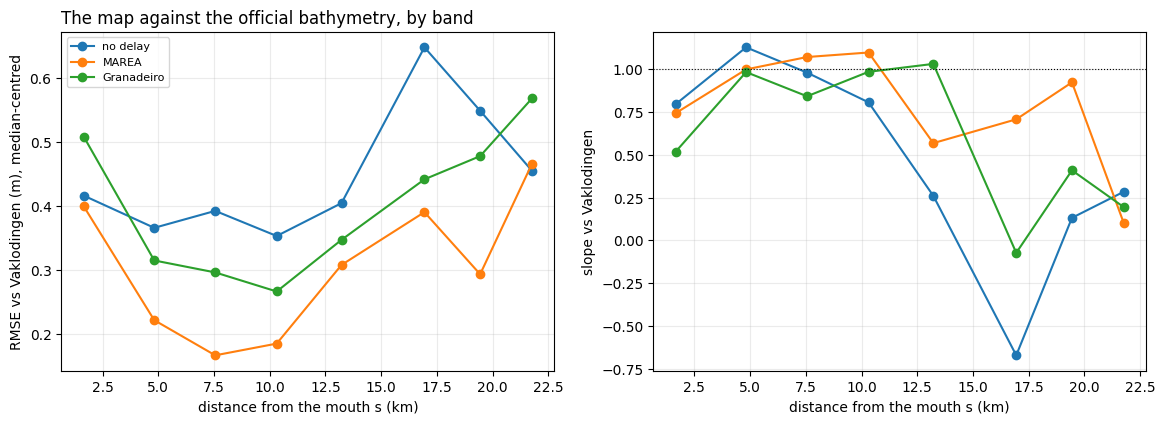

In [17]:
# Dutch sites: the Vaklodingen (the LiDAR cell above is skipped there)
from experiments import v1_vaklodingen_validate as v1
vak_table = None
if SITE in v1.SITES and os.path.exists("data_v4/truth/vaklodingen_catalog.nc"):
    import xarray as xr
    ds_ = xr.open_dataset(CACHE)
    xs_, ys_ = ds_["x"].values, ds_["y"].values
    ds_.close()
    to_rd = pyproj.Transformer.from_crs(crs, "EPSG:28992", always_xy=True)
    xq, yq = to_rd.transform(xs_[cols_k], ys_[rows_k])
    cells = v1.truth_grid(SITE)
    truth_v, tyear = v1.sample_truth(cells, xq, yq)
    lo_, hi_ = float(np.nanmin(z_plain)), float(np.nanmax(z_plain))
    in_range = (truth_v >= lo_ - 0.25) & (truth_v <= hi_ + 0.25)
    print(f"Vaklodingen at {int(np.isfinite(truth_v).sum()):,} px; "
          f"{int((np.isfinite(truth_v) & ~in_range).sum()):,} outside the products' tide range "
          f"[{lo_:+.2f}, {hi_:+.2f}] m excluded (channel below, ground above); "
          f"survey years {int(np.nanmin(tyear))}–{int(np.nanmax(tyear))}")
    truth_v = np.where(in_range, truth_v, np.nan)
    THIN_PX = max(1, int(round(100 / RESOLUTION_M)))     # one pixel per 100 m block (5 px at 20 m)
    thin = np.zeros(len(keep), bool); thin[np.unique((rows_k // THIN_PX) * 7919 + (cols_k // THIN_PX), return_index=True)[1]] = True

    def vscore(p, t):
        m = np.isfinite(p) & np.isfinite(t)
        if m.sum() < 30:
            return None
        pc, tc = p[m] - np.median(p[m]), t[m] - np.median(t[m])
        return dict(rmse_m=float(np.sqrt(np.mean((pc - tc) ** 2))), slope=float(np.polyfit(tc, pc, 1)[0]),
                    r=float(np.corrcoef(tc, pc)[0, 1]), bias_m=float(np.median(p[m] - t[m])), n=int(m.sum()))

    vprods = {"no delay": z_plain, "MAREA": z_marea}
    if gran is not None:
        vprods["Granadeiro"] = z_gran
    vcommon = np.isfinite(truth_v)
    for v_ in vprods.values():
        vcommon &= np.isfinite(v_)
    vrows = []
    for name_, v_ in vprods.items():
        a_ = vscore(v_, truth_v) or {}
        t_ = vscore(np.where(thin, v_, np.nan), truth_v) or {}
        c_ = vscore(np.where(vcommon, v_, np.nan), truth_v) or {}
        vrows.append({"product": name_, "n": a_.get("n"), "RMSE (m)": a_.get("rmse_m"), "slope": a_.get("slope"),
                      "r": a_.get("r"), "bias (m)": a_.get("bias_m"),
                      "thinned RMSE (m)": t_.get("rmse_m"), "thinned slope": t_.get("slope"),
                      "common RMSE (m)": c_.get("rmse_m"), "common slope": c_.get("slope"), "common r": c_.get("r")})
    vak_table = pd.DataFrame(vrows)
    print(f"common subset: {int(vcommon.sum()):,} px")
    display(vak_table.round(3))

    fig, axs = plt.subplots(1, 2, figsize=(14, 4.4))
    vband_rows = []
    for name_, v_ in vprods.items():
        bb_ = [vscore(np.where(band_of == k, v_, np.nan), truth_v) for k in range(len(centres))]
        axs[0].plot(centres, [b.get("rmse_m", np.nan) if b else np.nan for b in bb_], "o-", label=name_)
        axs[1].plot(centres, [b.get("slope", np.nan) if b else np.nan for b in bb_], "o-", label=name_)
        for k, b in enumerate(bb_):
            vband_rows.append({"product": name_, "band": k, "s_km": float(centres[k]),
                               "tau_applied_min": float(tau_used[k]),
                               **{kk: (b or {}).get(kk, np.nan) for kk in ("n", "rmse_m", "slope", "r", "bias_m")}})
    pd.DataFrame(vband_rows).to_csv(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/vaklodingen_by_band.csv", index=False)
    axs[0].set_ylabel("RMSE vs Vaklodingen (m), median-centred"); axs[1].set_ylabel("slope vs Vaklodingen")
    axs[1].axhline(1, color="k", lw=0.8, ls=":")
    for ax in axs:
        ax.set_xlabel("distance from the mouth s (km)"); ax.grid(alpha=0.25)
    axs[0].legend(fontsize=8)
    axs[0].set_title("The map against the official bathymetry, by band", loc="left")
    os.makedirs(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}", exist_ok=True)
    vak_table.to_csv(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/vaklodingen_metrics.csv", index=False)
else:
    print(f"no Vaklodingen coverage for {SITE!r}: this block is skipped")

## 11 · Summary and provenance

In [ ]:
summary = []
for name, z in [("no delay", z_plain), ("MAREA", z_marea)] + (
        [("crossed (their lag, our inversion)", z_cross), ("Granadeiro", z_gran)] if gran is not None else []):
    summary.append({"product": name, "px mapped": int(np.isfinite(z).sum()),
                    "median z (m)": float(np.nanmedian(z)),
                    "median |Δz| vs plain (m)": float(np.nanmedian(np.abs(z - z_plain)))})
print(f"boundary: {boundary.name}   ·   judge: {', '.join(judges)}")
display(pd.DataFrame(summary).round(3))
print("\nlag against the gauge pair:")
display(pair_table)
print("\nlevel error at the judge, with and without the lag:")
display(judge_table.round(4))

os.makedirs(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}", exist_ok=True)
np.savez_compressed(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/products.npz",
                    keep=keep, shape=np.array([H, W]), s_km=s_km, band=band_of,
                    z_plain=z_plain, z_marea=z_marea, z_marea_fit=z_marea_fit,
                    record_dates=np.asarray(ex["dates"][have])[okh], level_range=np.array([lo, hi]),
                    **({"z_cross": z_cross, "z_gran": z_gran, "lag_all": lag_all} if gran is not None else {}))
band_table.to_csv(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/marea_effect_by_band.csv", index=False)
print(f"\n-> {OUT_DIR}/comparison_{BOUNDARY_TAG}/")
explain.draw_graph(log)

## Notes

* **Grid.** 10 m since 2026-09-30, the grid of every site (the earlier 20 m
  runs kept three years of the box tractable on a laptop disk; they are
  archived in `products_<site>/` and `results/backup_all_scenes_2026-09-29/`).
  Every product here is on that grid; the Vaklodingen reference stays on
  its 20 m RD cells.
* **Datum.** The boundary is demeaned gauge level, model MSL, or their mean;
  elevations are relative to it. Map differences are reported raw and
  median-centred; level errors are median-centred (datum-free).
* **Same extraction for both methods.** `marea.extract` defines the pixels
  and the clear-sky mask; Granadeiro's NIR was read at those pixels. The
  pipeline mask of section 4 (polygon-clipped, 0.05–0.95) is the product
  mask; the extraction (0.10–0.90, no clip) is the estimation record.
* **Scene rule.** MAREA and "no delay" use the method's transition-zone
  cloud screening (the usable dates of section 3) at every site, the same
  rule as the Villaviciosa product; clouds inside kept scenes are masked per
  pixel. Rebuilt 2026-09-30 (author's decision); the lag fit accepts a
  record of `MIN_SCENES` scenes or more.
* **Granadeiro rows in this notebook** come from the superseded
  reimplementation below; the comparison tables of the paper use the
  faithful reimplementation (`experiments/v8_granadeiro2021.py`) scored with
  every method in one script.
* **Granadeiro substitutions** (declared in `experiments/sota_granadeiro.py`):
  Sen2Cor instead of ACOLITE, scipy least-squares instead of `nplr`, scipy
  thin-plate RBF instead of `mgcv`, lag sample of 1000 pixels, and the
  scene rule: their "< 10 % cloud over the whole frame" is replaced by
  "at most 20 % of the intertidal pixels cloudy", clouds still masked per
  pixel — on the Scheldt the frame rule left 33 scenes (11 rising, and
  their logistic needs 12) because the frame is mostly sea and far land.
* **Distance axis.** `s` is the geodesic distance through water from the
  sea on the `MOUTH_SIDE` edge(s). Pixels no water path reaches
  have no `s` and fall in no band.
* **Reserved data.** Nothing here touches the Villaviciosa RTK blocks; the
  only truth is the held-out gauge.